In [153]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

In [182]:
df = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed']

In [183]:
cols_to_remove = ['BrO_Error', 'NO2_Error', 'O3_Error']
data = df.drop(columns = cols_to_remove)

In [184]:
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [185]:
def add_specific_lags(df):
    df = df.copy()
    
    # df['NO2_column_density_lag1'] = df['NO2_column_number_density'].shift(1)
    df['nmvoc_lag1'] = df['nmvoc'].shift(1)
    # df['strat_NO2_lag1'] = df['stratospheric_NO2_column_number_density'].shift(1)
    df['H2O_column_lag1'] = df['H2O_column_number_density'].shift(1)
    df['nh3_lag1'] = df['nh3'].shift(1)
    
    # df['NO2_slant_density_lag2'] = df['NO2_slant_column_number_density'].shift(2)
    
    # df['aerosol_index_lag8'] = df['absorbing_aerosol_index'].shift(8)
    # df['NO2_pure_lag9'] = df['NO2'].shift(9)
    
    return df

data = add_specific_lags(data)
data = data.dropna().reset_index(drop=True)

In [ ]:
original_pollutants = [
    # 'NO2_slant_column_number_density', 
    # 'absorbing_aerosol_index', 
    # 'NO2_column_number_density', 
    # 'NO2', 
    'nmvoc', 
    # 'stratospheric_NO2_column_number_density', 
    'H2O_column_number_density', 
    'nh3'
]

data = data.drop(columns=original_pollutants)

In [187]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)
data = data.dropna(subset=['target_precipitation'])

In [188]:
train_end = '2024-07-01'
val_end = '2025-02-01'

train = data[data['observationTime'] < train_end]
val   = data[(data['observationTime'] >= train_end) & (data['observationTime'] <= val_end)]
test  = data[data['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2191, 32), nuo 2018-07-02 00:00:00 iki 2024-06-30 00:00:00
Val: (216, 32), nuo 2024-07-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 32),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [189]:
target_col = 'target_precipitation'
drop_cols = ['missforest_precipitation','observationTime', 't2m', target_col]

X_train = train.drop(columns=drop_cols)
y_train = train[target_col]

X_val = val.drop(columns=drop_cols)
y_val = val[target_col]

X_test = test.drop(columns=drop_cols)
y_test = test[target_col]

In [190]:
stand_model = XGBRegressor(random_state=2026)
stand_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [191]:
val_preds = stand_model.predict(X_val)

mae = mean_absolute_error(y_val, val_preds)
r2 = r2_score(y_val, val_preds)

print(f"Vidutinė paklaida (MAE): {mae:.2f}")
print(f"R2 koeficientas: {r2:.2f}")

Vidutinė paklaida (MAE): 1.69
R2 koeficientas: 0.30


In [192]:
plot_df = val[['observationTime', 'target_precipitation']].copy()
plot_df['prediction'] = val_preds
plot_df = plot_df.sort_values('observationTime')

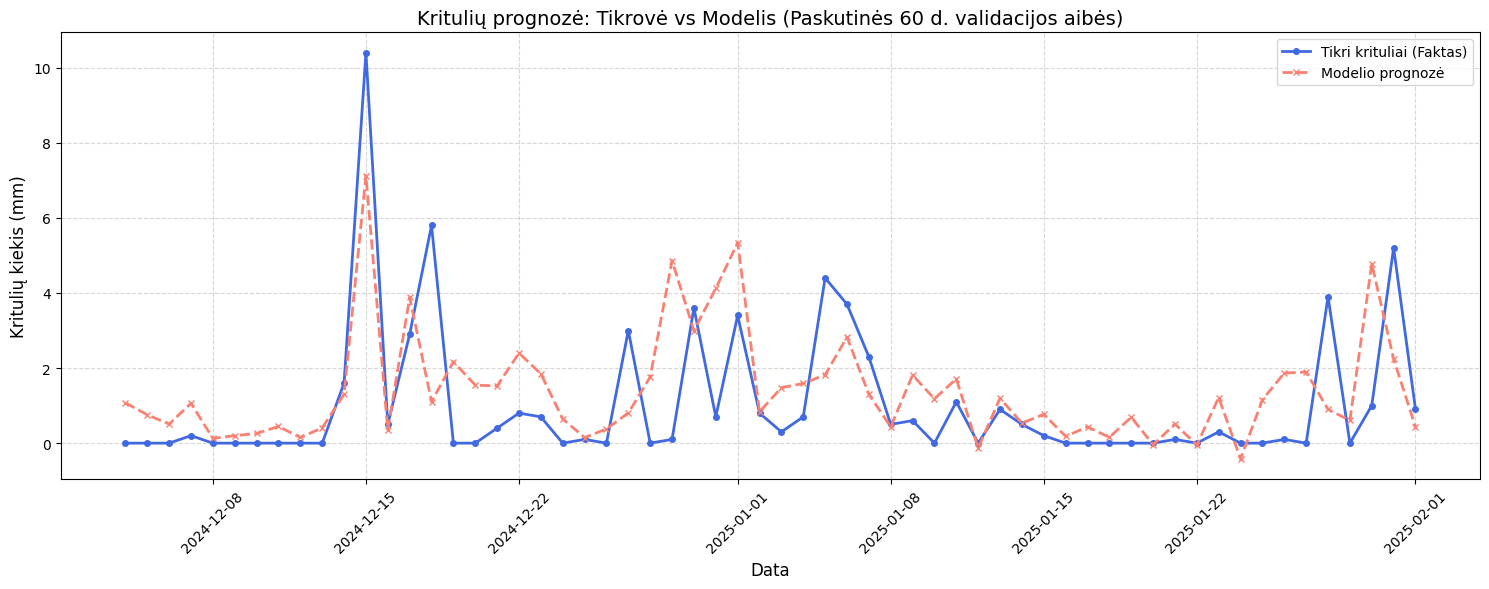

In [193]:
recent_df = plot_df.tail(60)

plt.figure(figsize=(15, 6))

# Tikri krituliai
plt.plot(recent_df['observationTime'], recent_df['target_precipitation'], 
         label='Tikri krituliai (Faktas)', color='royalblue', linewidth=2, marker='o', markersize=4)

# Modelio prognozė
plt.plot(recent_df['observationTime'], recent_df['prediction'], 
         label='Modelio prognozė', color='salmon', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('Kritulių prognozė: Tikrovė vs Modelis (Paskutinės 60 d. validacijos aibės)', fontsize=14)
plt.ylabel('Kritulių kiekis (mm)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45) # Pasukame datas, kad tilptų
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

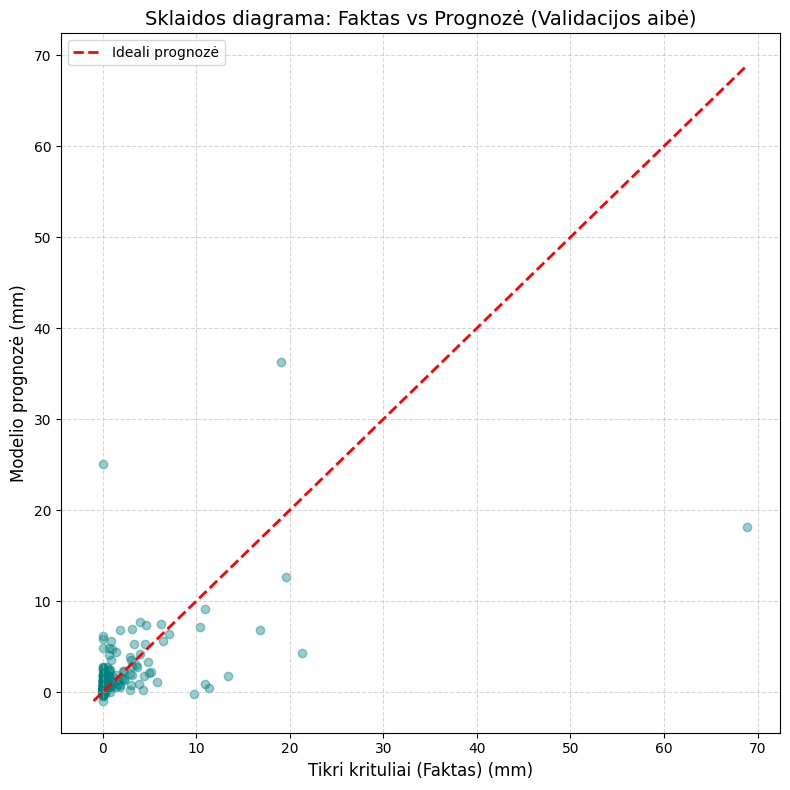

In [194]:
plt.figure(figsize=(8, 8))

# Taškai
plt.scatter(plot_df['target_precipitation'], plot_df['prediction'], alpha=0.4, color='teal')

# Ideali linija (Kur Faktas = Prognozė)
max_val = max(plot_df['target_precipitation'].max(), plot_df['prediction'].max())
min_val = min(plot_df['target_precipitation'].min(), plot_df['prediction'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideali prognozė')

plt.title('Sklaidos diagrama: Faktas vs Prognozė (Validacijos aibė)', fontsize=14)
plt.xlabel('Tikri krituliai (Faktas) (mm)', fontsize=12)
plt.ylabel('Modelio prognozė (mm)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [195]:
corr, p_value = spearmanr(y_val, val_preds)

print(f"Spearmano koreliacijos koeficientas: {corr:.3f}")

Spearmano koreliacijos koeficientas: 0.586


<Figure size 1000x800 with 0 Axes>

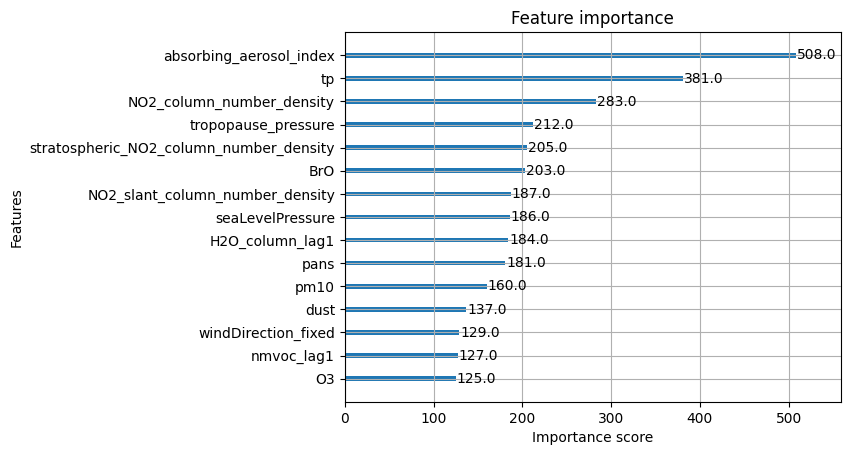

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(stand_model, max_num_features=15, importance_type='weight') 
plt.show()

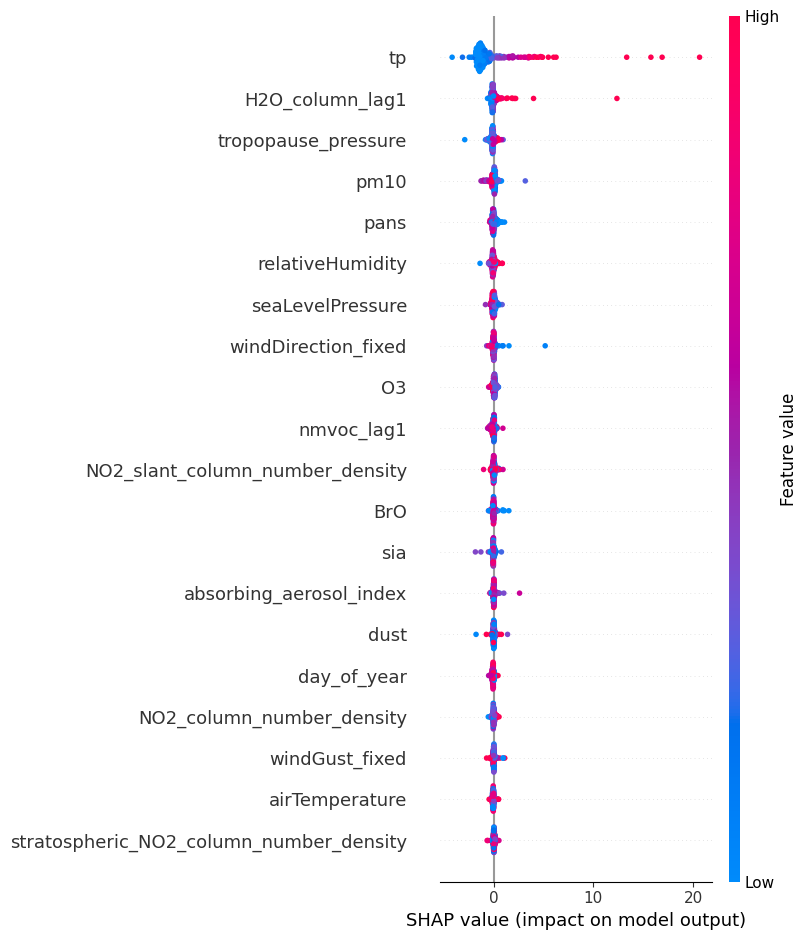

In [197]:
import shap

explainer = shap.TreeExplainer(stand_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)